In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

def zero_mean(x: np.ndarray):
    return np.zeros(x.shape[0])

def rbf(x1: np.ndarray, x2: np.ndarray, sigma2: float = 1.0, l: np.ndarray | float = 1.0) -> np.ndarray:
    d = (x1[:, None] - x2[None, :]) / l
    d2 = (d**2).sum(axis=-1)
    return sigma2 * np.exp(-0.5 * d2)


class GaussianProcess:
    def __init__(self, m, k, sigma2_noise: float = 0.0):
        self.m_init = m
        self.k_init = k
        self.m = m
        self.k = k
        self.sigma2_noise = sigma2_noise

        self.x = None
        self.y = None

    def sample(self, x: np.ndarray) -> np.ndarray:
        return np.random.multivariate_normal(self.m(x), self.k(x, x))

    def observe(self, x_obs: np.ndarray, y_obs: np.ndarray):
        self.x = x_obs if self.x is None else np.concat((self.x, x_obs), axis=0)
        self.y = y_obs if self.y is None else np.concat((self.y, y_obs), axis=0)

        # Update m.
        A = self.k_init(self.x, self.x) + (self.sigma2_noise + 1e-9)*np.identity(self.x.shape[0])
        L = np.linalg.cholesky(A, upper=False)

        a = scipy.linalg.solve_triangular(L, self.y - self.m_init(self.x), lower=True)
        b = scipy.linalg.solve_triangular(L.T, a, lower=False)

        def new_m(x_new: np.ndarray) -> np.ndarray:
            return self.m_init(x_new) + self.k_init(x_new, self.x) @ b
        self.m = new_m

        # Update k.
        def new_k(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
            a = scipy.linalg.solve_triangular(L, self.k_init(self.x, x2), lower=True)
            b = scipy.linalg.solve_triangular(L.T, a, lower=False)
            return self.k_init(x1, x2) - self.k_init(x1, self.x) @ b
        self.k = new_k


def plot_gp(gp: GaussianProcess, x_new: np.ndarray, ax):
    assert (x_new.ndim == 2) and (x_new.shape[1] == 1)
    mu_new = gp.m(x_new)
    ax.plot(x_new[:, 0], mu_new, "k", label=r"$\mu$")

    sigma2_new = np.diag(gp.k(x_new, x_new))
    sigma_new = np.sqrt(np.maximum(sigma2_new, 0.0))
    ax.fill_between(x_new[:, 0], mu_new - 2*sigma_new, mu_new + 2*sigma_new,
                    color="blue", alpha=0.3, label=r"$\mu \pm 2\sigma$")

    if not (gp.x is None):
        ax.scatter(gp.x[:, 0], gp.y)

def plot_gp_k(gp: GaussianProcess, x_new: np.ndarray, ax):
    img = ax.imshow(gp.k(x_new, x_new))
    return img

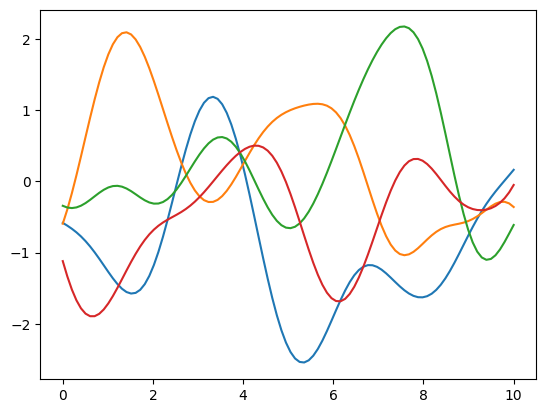

In [43]:
gp = GaussianProcess(m=zero_mean, k=rbf)

x_new = np.linspace(0, 10, 100)[:, None]
for i in range(4):
    plt.plot(x_new, gp.sample(x_new))
plt.show()

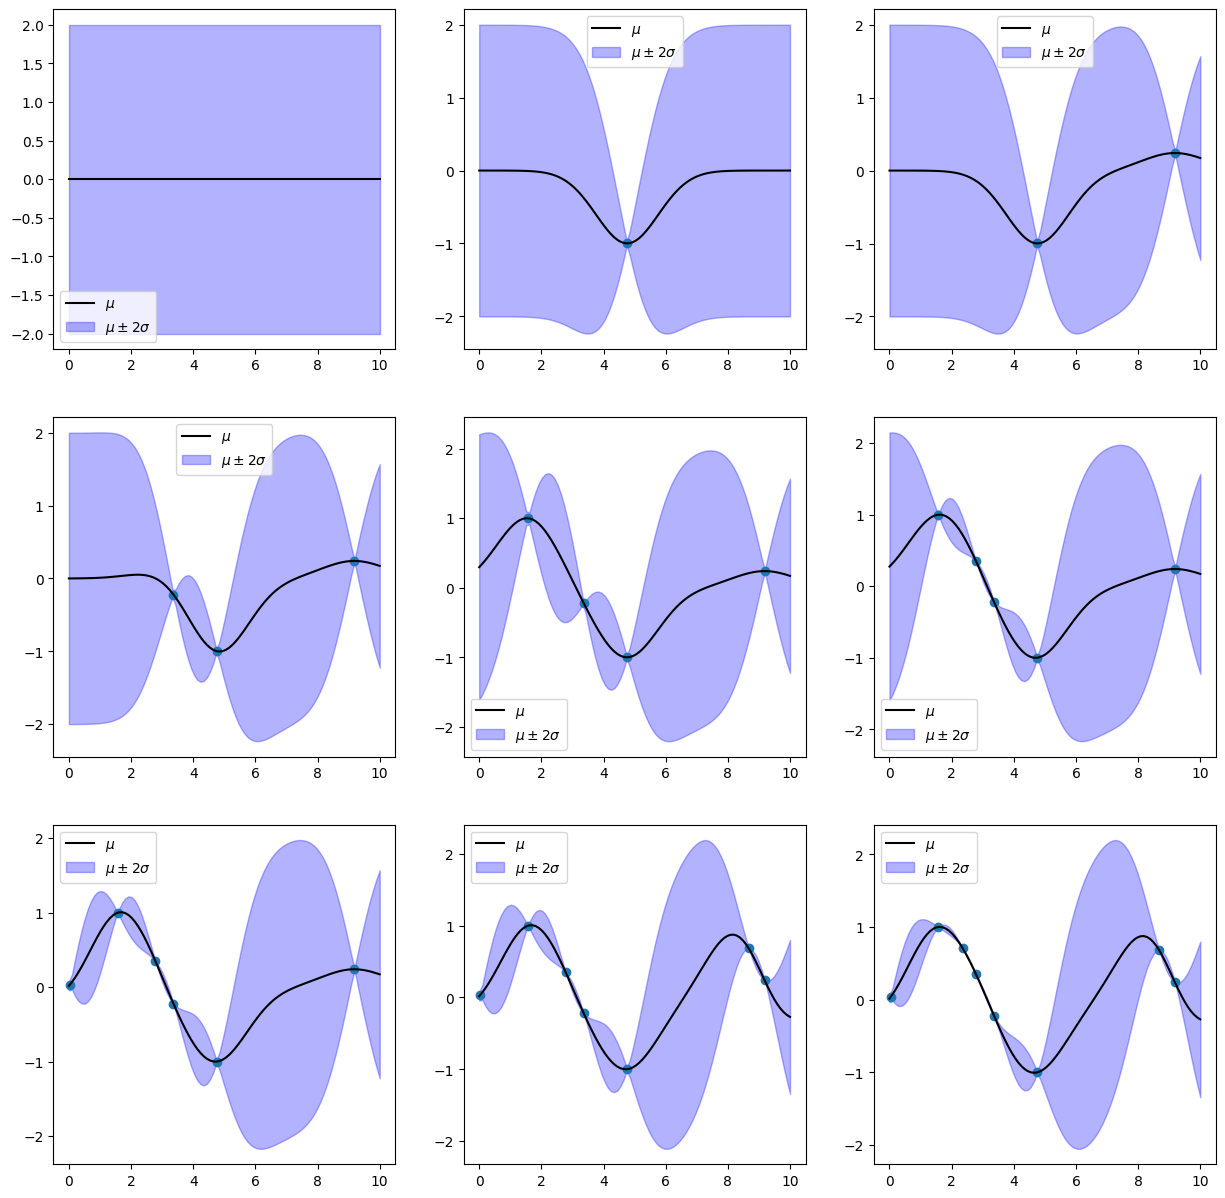

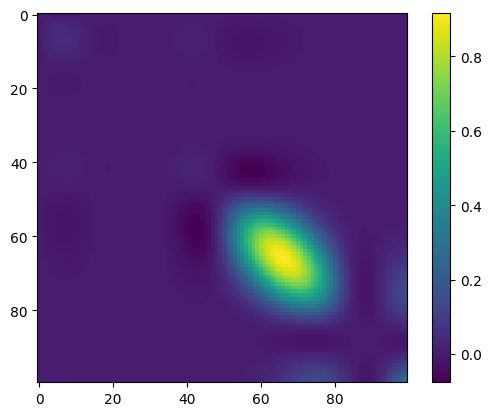

In [44]:
f = np.sin
gp = GaussianProcess(m=zero_mean, k=rbf)


fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

x_new = np.linspace(0, 10, 100)[:, None]
plot_gp(gp, x_new, axs.flat[0])
axs.flat[0].legend(loc=0)

for ax in axs.flat[1:]:
    x = np.random.random(1) * 10
    y = f(x)

    gp.observe(x[:, None], y)
    plot_gp(gp, x_new, ax)

    ax.legend(loc=0)
plt.show()


fig, ax = plt.subplots()
img = plot_gp_k(gp, x_new, ax)
plt.colorbar(img)
plt.show()

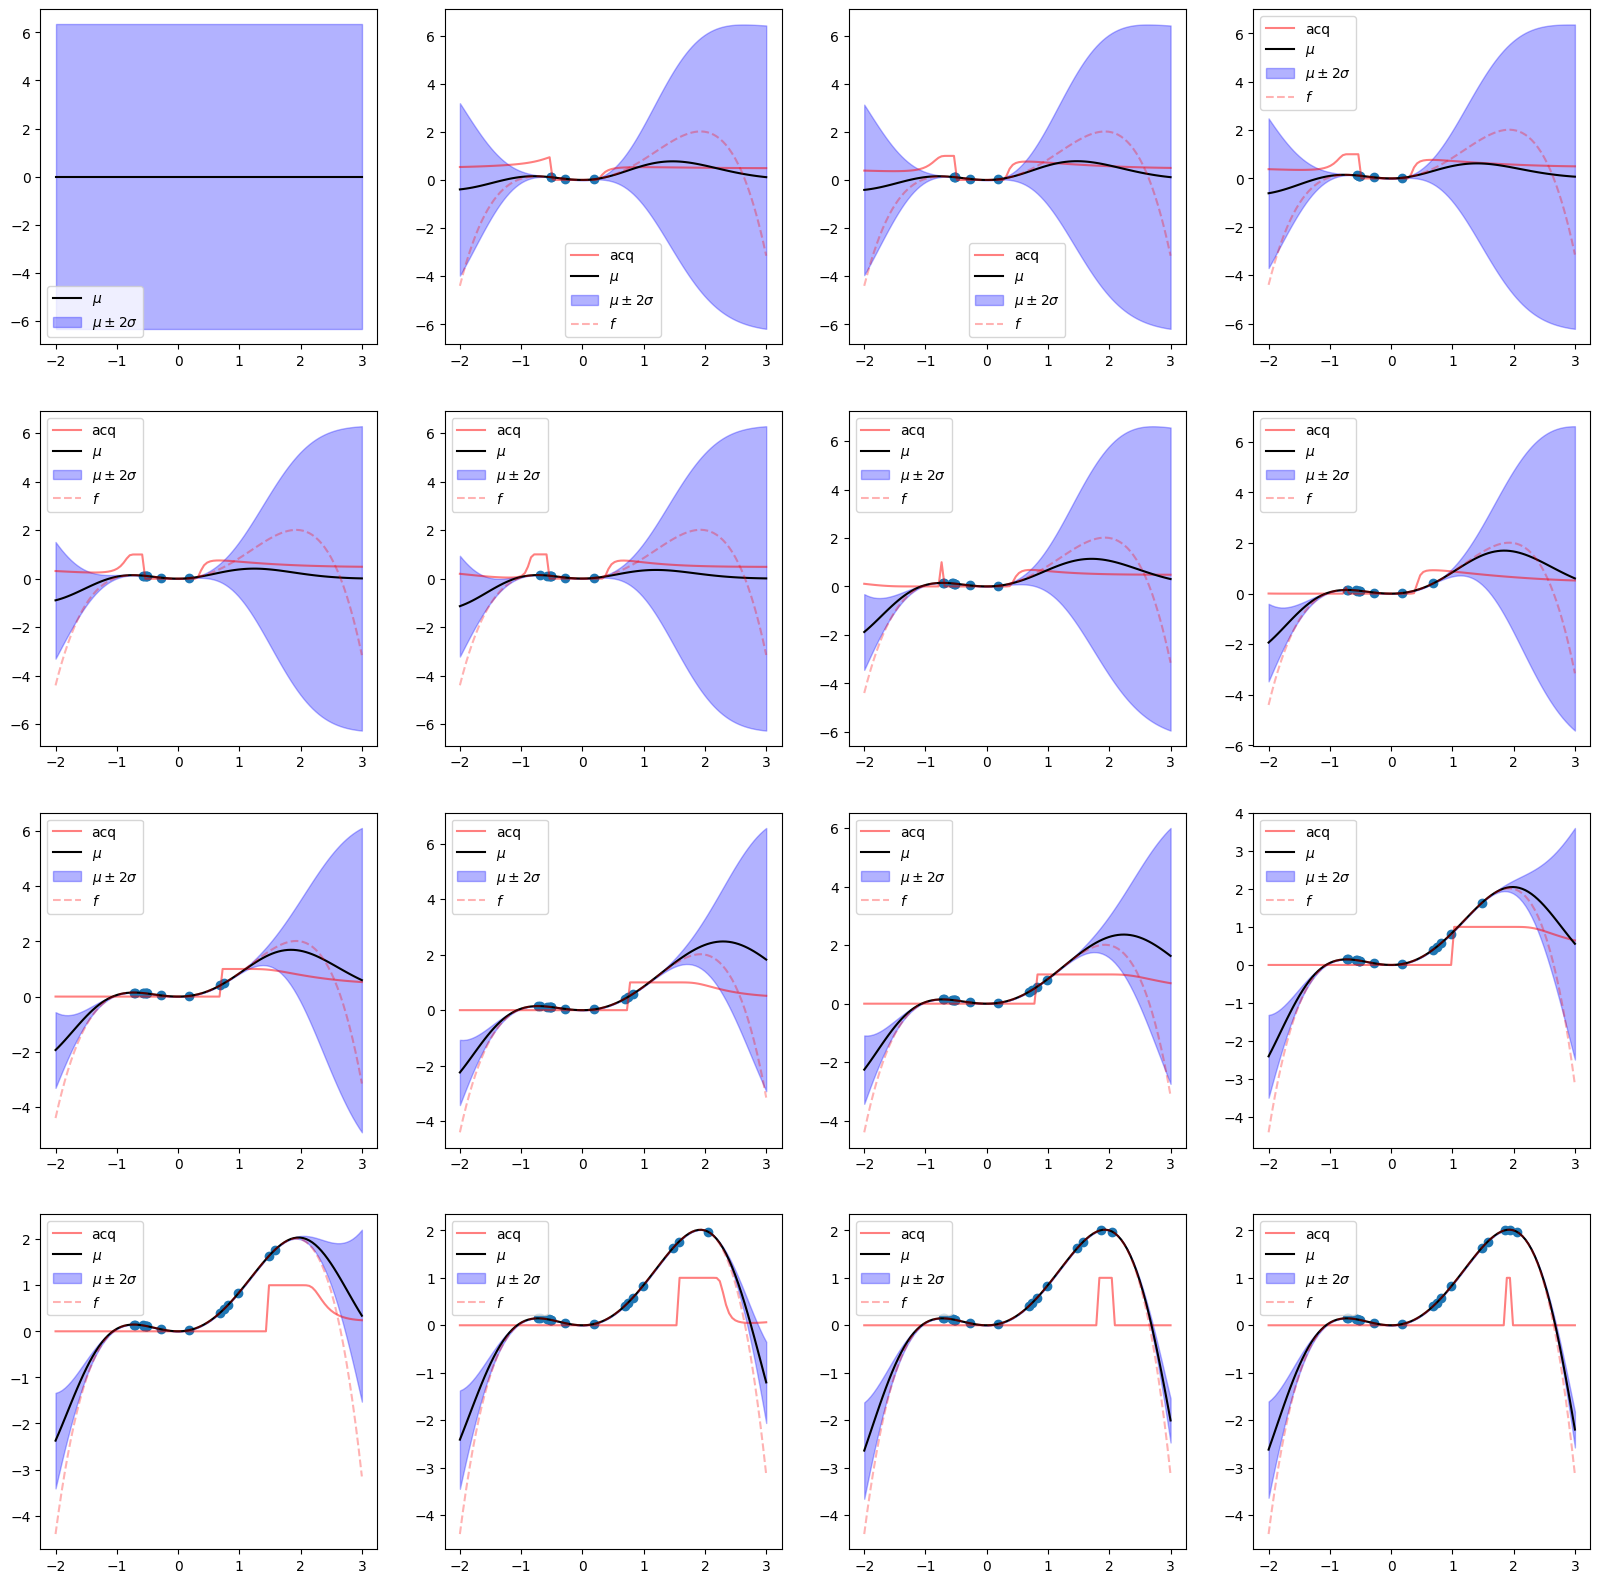

In [46]:
from functools import partial

def minimize(f, x_sampler, x_bounds: list[tuple[float, float]] = None, n_init_samples: int = 1000, n_starts: int = 10):
    x = x_sampler(n_init_samples)
    y = [f(xi) for xi in x]
    x = x[np.argsort(y)[:n_starts]]

    best_x = None
    best_y = float("inf")
    for x0 in x:
        res = scipy.optimize.minimize(f, x0=x0, bounds=x_bounds, method="L-BFGS-B")
        if res.fun < best_y:
            best_y = res.fun
            best_x = res.x
    return best_x


def p_improve(x: np.ndarray, best_y: float, gp: GaussianProcess):
    mu = gp.m(x)[0]
    sigma2 = gp.k(x, x)[0, 0]
    sigma = np.sqrt(np.maximum(sigma2, 0.0))
    return scipy.stats.norm.cdf((mu - best_y) / sigma)


def f(x: np.ndarray):
    return -0.25 * x[0]**4 + 0.4 * x[0]**3 + 0.7 * x[0]**2

x_bounds = [(-2.0, 3.0)]
x_sampler = lambda n: np.random.uniform(x_bounds[0][0], x_bounds[0][1], n)[:, None]


gp = GaussianProcess(m=zero_mean, k=partial(rbf, sigma2=10), sigma2_noise=0.0)
acq_func = partial(p_improve, gp=gp)


fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
x_new = np.linspace(x_bounds[0][0], x_bounds[0][1], 100)[:, None]
plot_gp(gp, x_new, axs.flat[0])
axs.flat[0].legend(loc=0)

x_init = x_sampler(3)
y_init = [f(xi) for xi in x_init]
gp.observe(x_init, y_init)

best_y = np.max(y_init)
for ax in axs.flat[1:]:
    ax.plot(x_new[:, 0], [acq_func(x=xi, best_y=best_y) for xi in x_new], "r", alpha=0.5, label=r"acq")

    x = minimize(lambda x: -acq_func(x=x, best_y=best_y), x_sampler, x_bounds)
    y = f(x)

    best_y = max(best_y, y)

    gp.observe(x[:, None], np.array([y]))
    plot_gp(gp, x_new, ax)

    ax.plot(x_new[:, 0], [f(xi) for xi in x_new], "r--", alpha=0.3, label=r"$f$")
    ax.legend(loc=0)
plt.show()

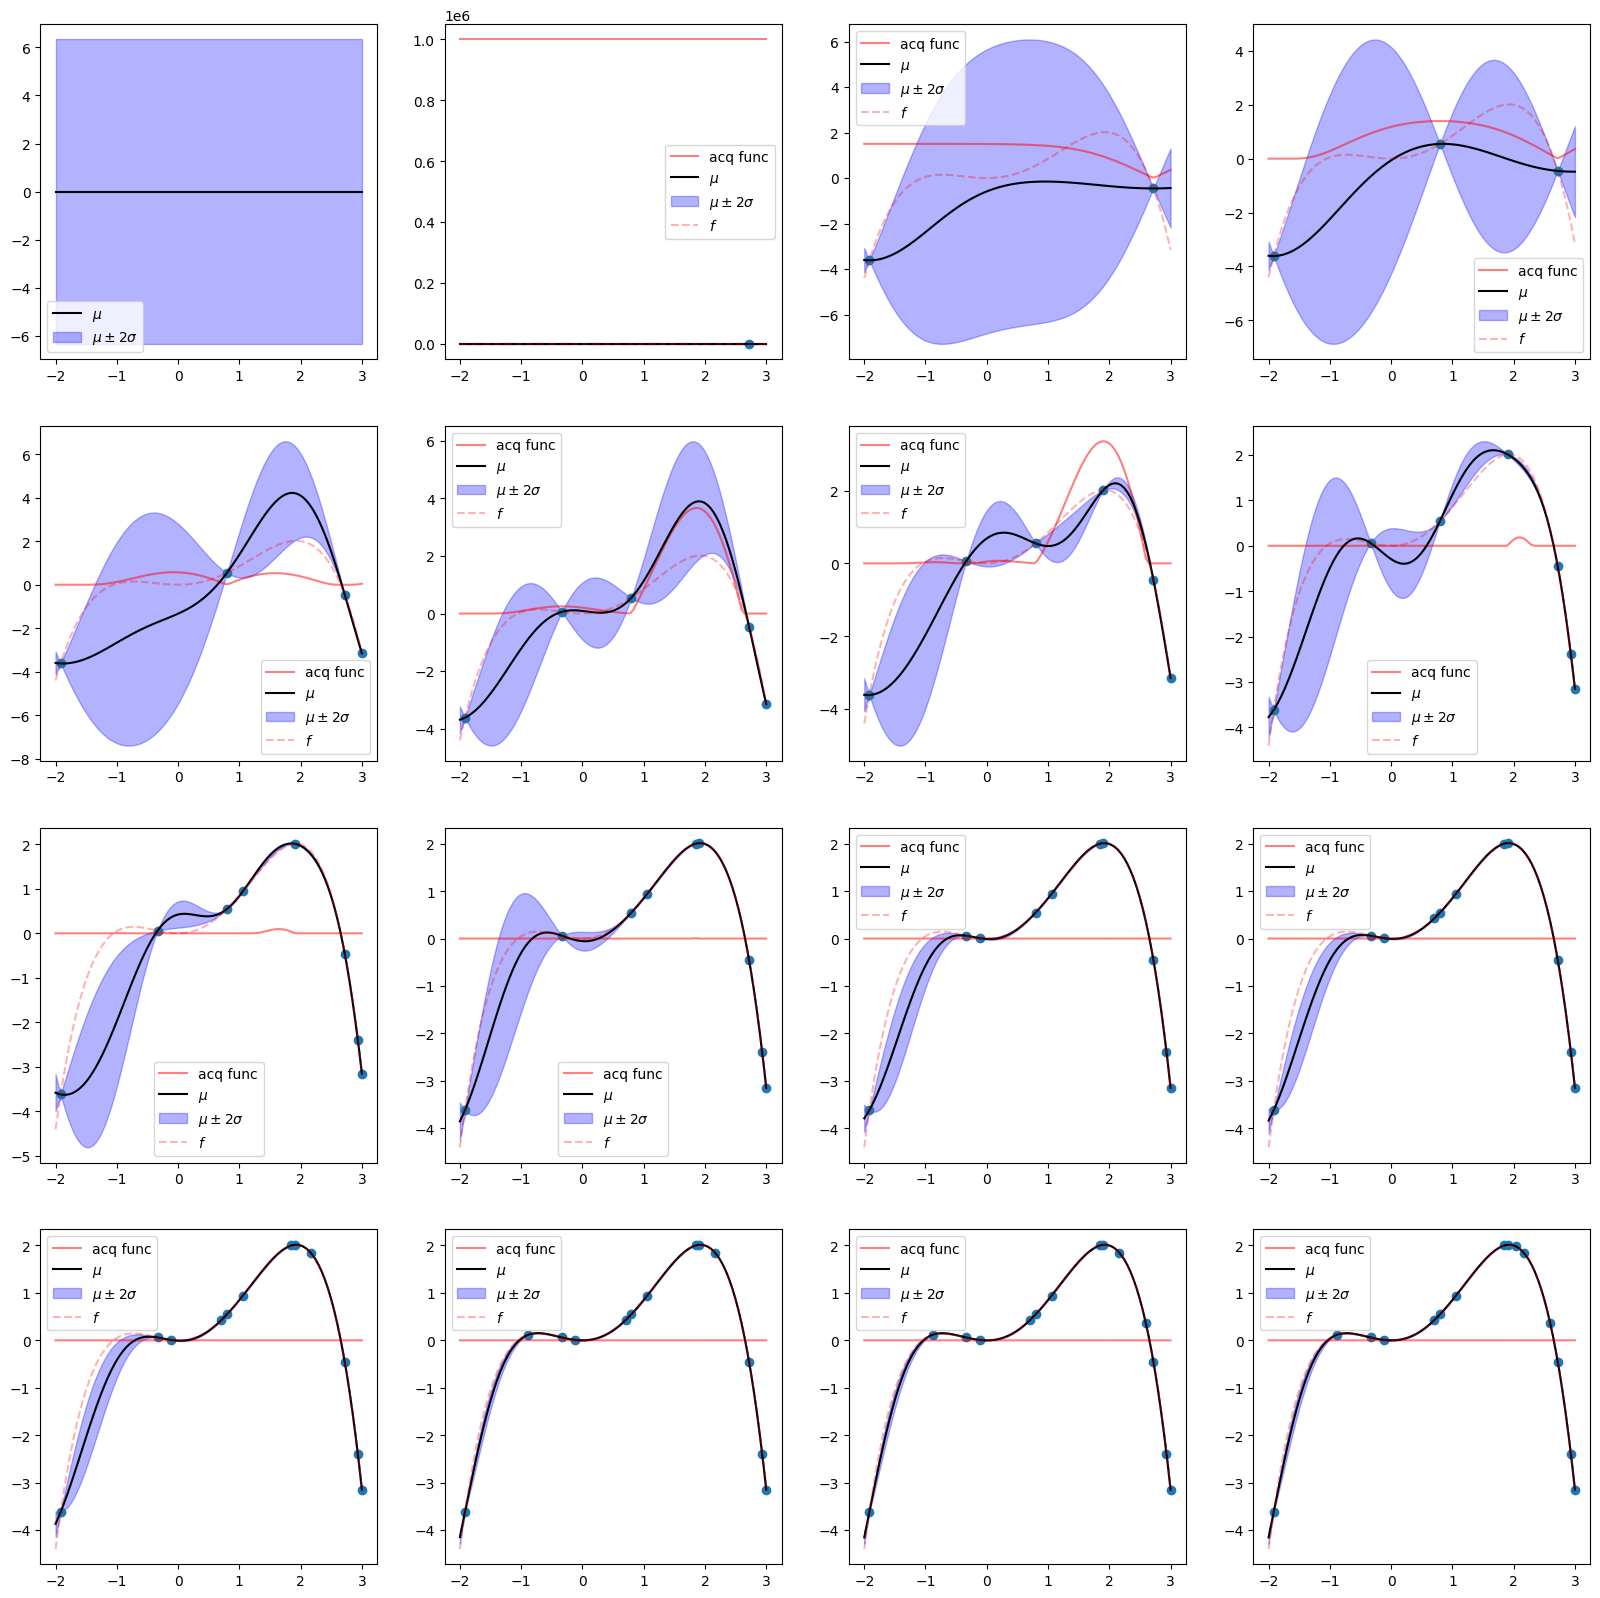

In [5]:
def E_improve(gp: GaussianProcess, x: float, y: float):
    x = np.array([x])
    mu = gp.m(x)[0]
    sigma = np.sqrt(gp.k(x, x)[0, 0] + 1e-8)
    z = (mu - y) / sigma
    return (mu - y) * scipy.stats.norm.cdf(z) + sigma * scipy.stats.norm.pdf(z)

def f(x):
    return -0.25 * x**4 + 0.4 * x**3 + 0.7 * x**2

m = np.zeros_like
k = partial(rbf, sigma2=10)
gp = GaussianProcess(m=m, k=k, sigma2_noise=1e-6)


fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
x_new = np.linspace(-2, 3, 100)
gp.plot(axs.flat[0], x_new)
axs.flat[0].legend(loc=0)

best_y = -1000000
for ax in axs.flat[1:]:
    ax.plot(x_new, [E_improve(gp, xi, best_y) for xi in x_new], "r", alpha=0.5, label=r"acq func")

    x = minimize(lambda x: -E_improve(gp, x, best_y), lambda n: np.random.random(n) * 5 - 2, x_bounds=(-2, 3))
    y = f(x)

    best_y = max(best_y, y)

    gp.observe(x, y)
    gp.plot(ax, x_new)

    ax.plot(x_new, f(x_new), "r--", alpha=0.3, label=r"$f$")
    ax.legend(loc=0)
plt.show()

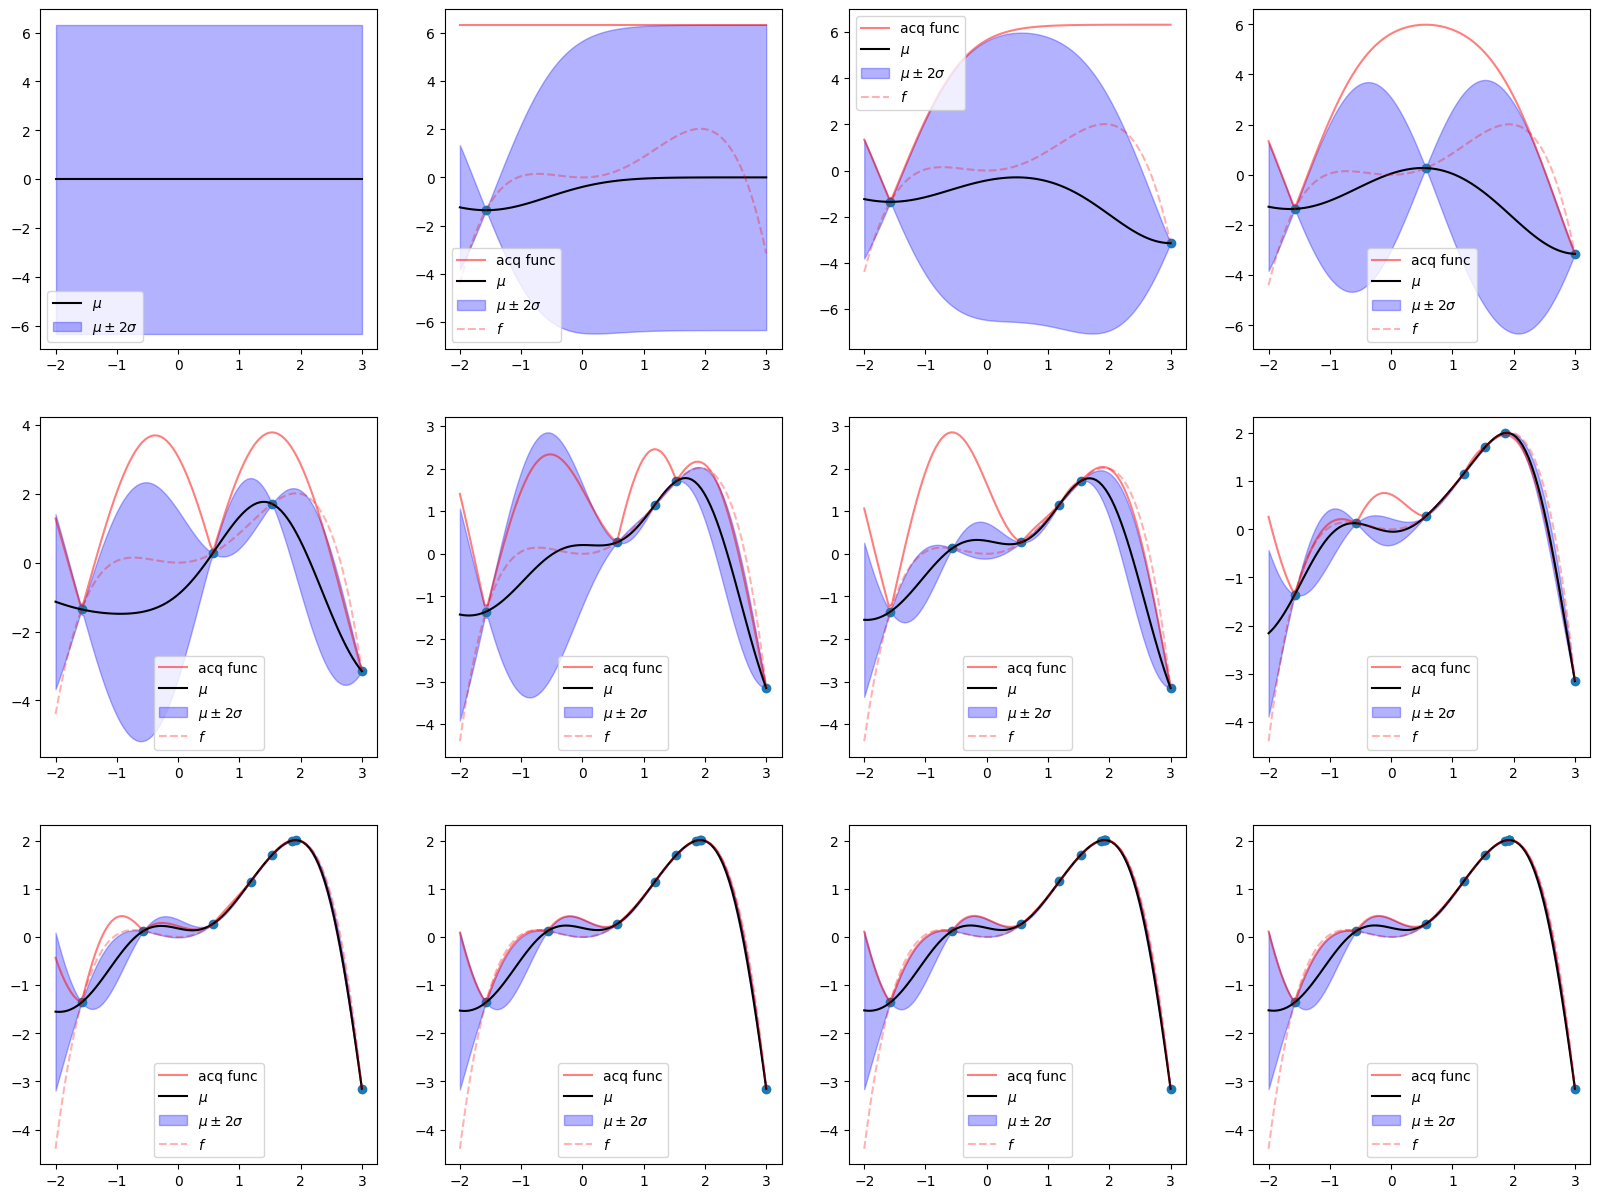

In [6]:
def ucb(x: float, gp: GaussianProcess, c: float):
    x = np.array([x])
    mu = gp.m(x)[0]
    sigma = np.sqrt(gp.k(x, x)[0, 0] + 1e-8)
    return mu + c*sigma

def f(x):
    return -0.25 * x**4 + 0.4 * x**3 + 0.7 * x**2

m = np.zeros_like
k = partial(rbf, sigma2=10)
gp = GaussianProcess(m=m, k=k, sigma2_noise=1e-6)


fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
x_new = np.linspace(-2, 3, 100)
gp.plot(axs.flat[0], x_new)
axs.flat[0].legend(loc=0)

ucb_func = partial(ucb, gp=gp, c=2)

for ax in axs.flat[1:]:
    ax.plot(x_new, [ucb_func(xi) for xi in x_new], "r", alpha=0.5, label=r"acq func")

    x = minimize(lambda x: -ucb_func(x), lambda n: np.random.random(n) * 5 - 2, x_bounds=(-2, 3))
    y = f(x)

    gp.observe(x, y)
    gp.plot(ax, x_new)

    ax.plot(x_new, f(x_new), "r--", alpha=0.3, label=r"$f$")
    ax.legend(loc=0)
plt.show()